In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
salud = "/workspaces/correaliesel138-a11y-intro-ml/data/raw/Global Health Statistics.csv" #ESTE LINK ES DEL DATASET QUE ESTA EN LA PAGINA DE KAGGLE
df = pd.read_csv(salud)
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   Country                             1000000 non-null  object 
 1   Year                                1000000 non-null  int64  
 2   Disease Name                        1000000 non-null  object 
 3   Disease Category                    1000000 non-null  object 
 4   Prevalence Rate (%)                 1000000 non-null  float64
 5   Incidence Rate (%)                  1000000 non-null  float64
 6   Mortality Rate (%)                  1000000 non-null  float64
 7   Age Group                           1000000 non-null  object 
 8   Gender                              1000000 non-null  object 
 9   Population Affected                 1000000 non-null  int64  
 10  Healthcare Access (%)               1000000 non-null  float64
 11  Doctors per 

In [4]:
#print(df['country'].head(20))
df = df.drop_duplicates(subset = df.columns.difference(['PassengerId']))
print(df.shape)
df.head()

(1000000, 22)


,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007,...,7.58,Medication,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318,...,5.11,Surgery,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878,...,3.49,Vaccination,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224,...,8.44,Surgery,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908,...,5.90,Medication,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


In [5]:
#df.drop("PassengerId", axis = 1).duplicated().sum()
#df.duplicated().sum()
#df.drop(, axis = 1).duplicated().sum() #

print(df['Country'].value_counts())

Country
Russia          50532
South Africa    50408
South Korea     50181
Germany         50176
UK              50125
Canada          50114
Mexico          50080
China           50066
Nigeria         50046
Saudi Arabia    49958
Australia       49953
France          49943
USA             49913
Turkey          49901
Italy           49839
Argentina       49798
Japan           49764
India           49760
Indonesia       49756
Brazil          49687
Name: count, dtype: int64


In [6]:
print(df['Country'].unique())
print(f"Total países: {df['Country'].nunique()}")

['Italy' 'France' 'Turkey' 'Indonesia' 'Saudi Arabia' 'USA' 'Nigeria'
 'Australia' 'Canada' 'Mexico' 'China' 'South Africa' 'Japan' 'UK'
 'Russia' 'Brazil' 'Germany' 'India' 'Argentina' 'South Korea']


Total países: 20


In [7]:
print(f"nombre de enfermedades: {df['Disease Name'].value_counts().shape[0]}")
print(df['Disease Name'].value_counts())
print(df['Disease Name'].unique())
print(f"Total enfermedades: {df['Disease Name'].nunique()}")

nombre de enfermedades: 20
Disease Name
COVID-19               50404
Zika                   50313
Dengue                 50289
Cancer                 50285
HIV/AIDS               50274
Cholera                50249
Asthma                 50122
Leprosy                50064
Diabetes               50020
Rabies                 49975
Hepatitis              49970
Polio                  49956
Malaria                49948
Influenza              49919
Tuberculosis           49862
Alzheimer's Disease    49823
Measles                49736
Parkinson's Disease    49708
Ebola                  49692
Hypertension           49391
Name: count, dtype: int64
['Malaria' 'Ebola' 'COVID-19' "Parkinson's Disease" 'Tuberculosis'
 'Dengue' 'Rabies' 'Cholera' 'Leprosy' 'Cancer' 'Diabetes' 'Measles'
 'Zika' "Alzheimer's Disease" 'Polio' 'Hypertension' 'Asthma' 'HIV/AIDS'
 'Influenza' 'Hepatitis']
Total enfermedades: 20


In [40]:
print(df['Mortality Rate (%)'].describe())
print(df['Per Capita Income (USD)'].describe())

count    1000000.000000
mean           5.049919
std            2.859427
min            0.100000
25%            2.580000
50%            5.050000
75%            7.530000
max           10.000000
Name: Mortality Rate (%), dtype: float64
count    1000000.000000
mean       50311.099835
std        28726.959359
min          500.000000
25%        25457.000000
50%        50372.000000
75%        75195.000000
max       100000.000000
Name: Per Capita Income (USD), dtype: float64


/tmp/ipykernel_1408/462323112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_enfermedad.values, y=top_enfermedad.index, palette='Blues_r')


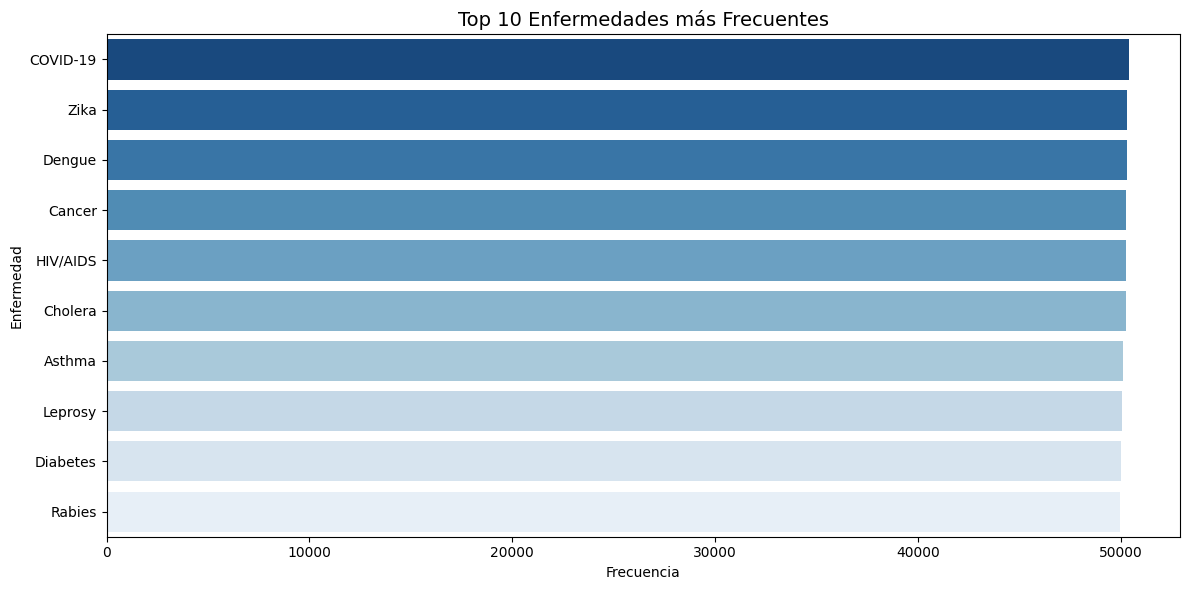

/tmp/ipykernel_1408/462323112.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mortalidad_pais.values, y=mortalidad_pais.index, palette='Reds_r')


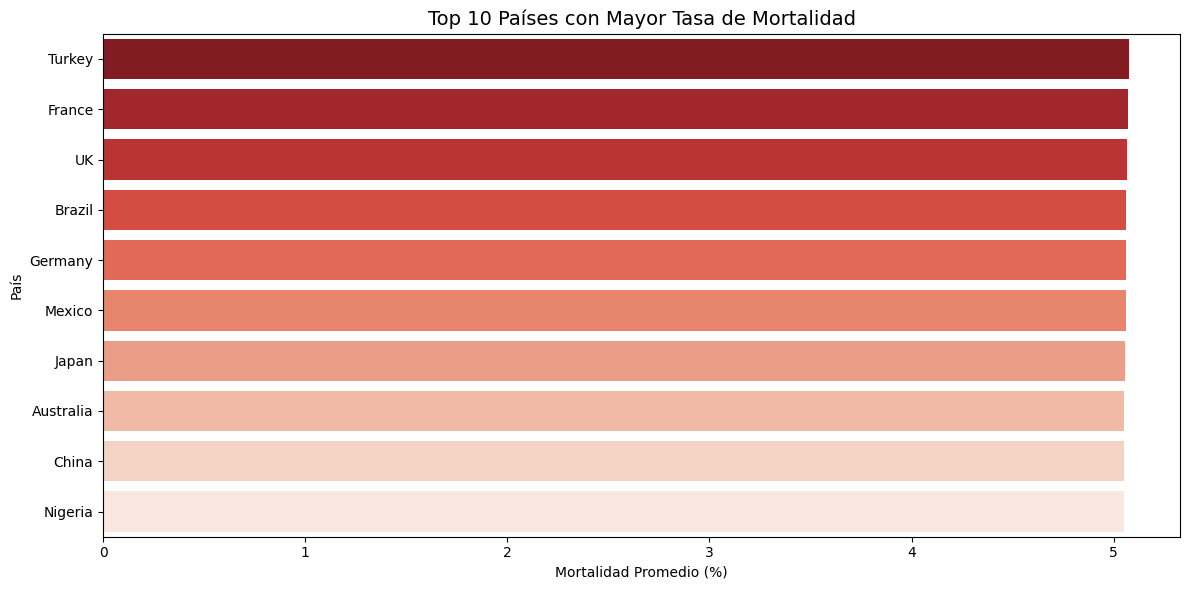

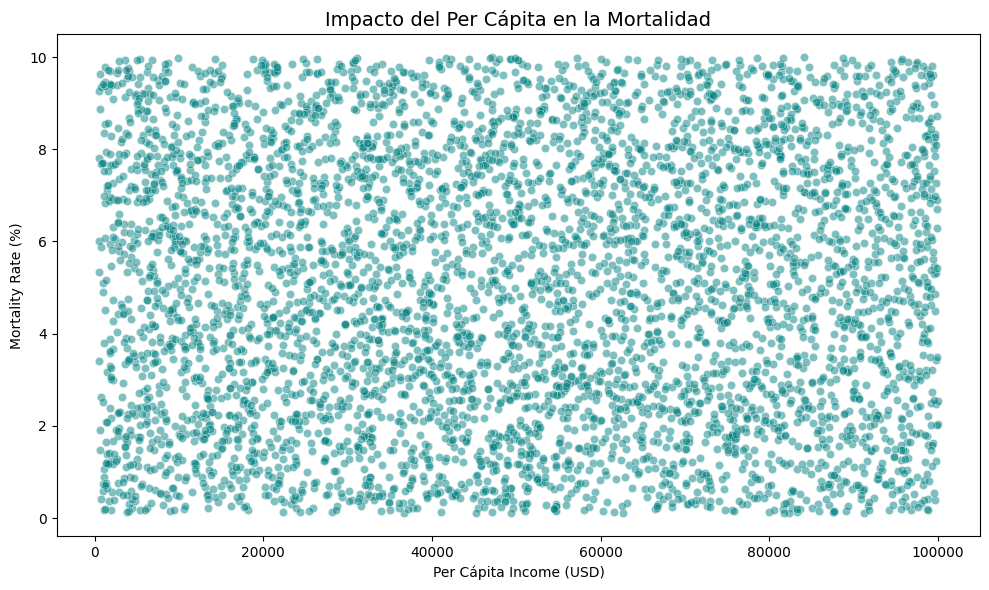

In [38]:
# =============================================
# GRÁFICA 1: Top 10 enfermedades más frecuentes
# =============================================
plt.figure(figsize=(12, 6))
top_enfermedad = df['Disease Name'].value_counts().head(10)
sns.barplot(x=top_enfermedad.values, y=top_enfermedad.index, palette='Blues_r')
plt.title('Top 10 Enfermedades más Frecuentes', fontsize=14)
plt.xlabel('Frecuencia')
plt.ylabel('Enfermedad')
plt.tight_layout()
plt.show()

# =============================================
# GRÁFICA 2: Top 10 países con mayor mortalidad
# =============================================
plt.figure(figsize=(12, 6))
mortalidad_pais = df.groupby('Country')['Mortality Rate (%)'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=mortalidad_pais.values, y=mortalidad_pais.index, palette='Reds_r')
plt.title('Top 10 Países con Mayor Tasa de Mortalidad', fontsize=14)
plt.xlabel('Mortalidad Promedio (%)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

# =============================================
# GRÁFICA 3: Relación entre Per Cápita y Mortalidad
# =============================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000),  # muestra para no sobrecargar
                x='Per Capita Income (USD)', 
                y='Mortality Rate (%)',
                alpha=0.5, color='teal')
plt.title('Impacto del Per Cápita en la Mortalidad', fontsize=14)
plt.xlabel('Per Cápita Income (USD)')
plt.ylabel('Mortality Rate (%)')
plt.tight_layout()
plt.show()

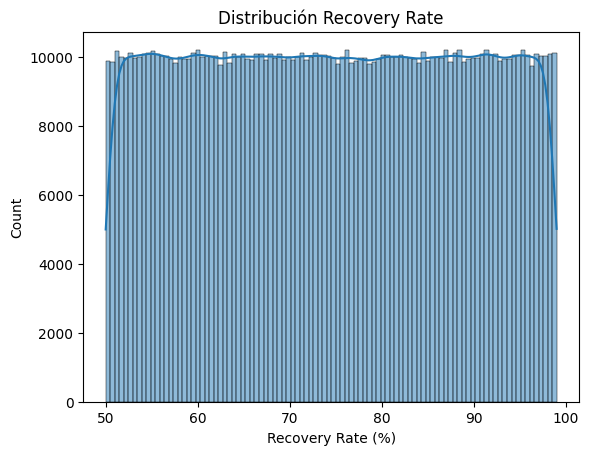

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Recovery Rate (%)"], kde=True)
plt.title("Distribución Recovery Rate")
plt.show()

In [15]:
# Elegir el país que quieres consultar
pais = "Japan"  # cambia por el país que quieras

# Cuántas enfermedades hay en ese país
print(f"Total enfermedades en {pais}: {df[df['Country'] == pais]['Disease Name'].nunique()}")

# Cuáles son
print(df[df['Country'] == pais]['Disease Name'].unique())

Total enfermedades en Japan: 20
['Diabetes' "Alzheimer's Disease" 'Malaria' 'Tuberculosis' 'Influenza'
 'Zika' 'Dengue' 'Rabies' 'Hypertension' 'Leprosy' "Parkinson's Disease"
 'Ebola' 'HIV/AIDS' 'COVID-19' 'Cancer' 'Hepatitis' 'Polio' 'Measles'
 'Cholera' 'Asthma']


In [16]:
df.groupby('Country')['Disease Name'].nunique()

Country
Argentina       20
Australia       20
Brazil          20
Canada          20
China           20
France          20
Germany         20
India           20
Indonesia       20
Italy           20
Japan           20
Mexico          20
Nigeria         20
Russia          20
Saudi Arabia    20
South Africa    20
South Korea     20
Turkey          20
UK              20
USA             20
Name: Disease Name, dtype: int64

In [17]:
df[df['Country'] == pais]['Disease Name'].value_counts()

Disease Name
HIV/AIDS               2611
Zika                   2555
Tuberculosis           2536
Ebola                  2524
Leprosy                2524
Dengue                 2521
Diabetes               2509
Cancer                 2493
Alzheimer's Disease    2487
COVID-19               2482
Asthma                 2475
Malaria                2473
Influenza              2472
Rabies                 2470
Hypertension           2449
Measles                2447
Polio                  2439
Parkinson's Disease    2438
Cholera                2431
Hepatitis              2428
Name: count, dtype: int64

In [18]:

print(f"nombre de categorías de enfermedades: {df['Disease Category'].value_counts().shape[0]}")
print(df['Disease Category'].value_counts())
print(df['Disease Category'].value_counts())
print(df['Disease Category'].unique())
print(f"Total enfermedades: {df['Disease Category'].nunique()}")

nombre de categorías de enfermedades: 11
Disease Category
Metabolic         91332
Parasitic         91178
Genetic           91153
Autoimmune        91153
Neurological      91000
Cardiovascular    90968
Viral             90910
Infectious        90764
Respiratory       90588
Bacterial         90509
Chronic           90445
Name: count, dtype: int64
Disease Category
Metabolic         91332
Parasitic         91178
Genetic           91153
Autoimmune        91153
Neurological      91000
Cardiovascular    90968
Viral             90910
Infectious        90764
Respiratory       90588
Bacterial         90509
Chronic           90445
Name: count, dtype: int64
['Respiratory' 'Parasitic' 'Genetic' 'Autoimmune' 'Bacterial'
 'Cardiovascular' 'Neurological' 'Chronic' 'Metabolic' 'Infectious'
 'Viral']
Total enfermedades: 11
